In [1]:
import os

# Install unrar-free for extracting .rar files
!apt-get update && apt-get install -y unrar-free

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,765 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,030 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-securi

In [2]:
# Download the iresnet.py file
!wget -P /content/ https://raw.githubusercontent.com/deepinsight/insightface/master/recognition/arcface_torch/backbones/iresnet.py

print("iresnet.py downloaded.")

--2026-06-24 11:16:34--  https://raw.githubusercontent.com/deepinsight/insightface/master/recognition/arcface_torch/backbones/iresnet.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7431 (7.3K) [text/plain]
Saving to: ‘/content/iresnet.py’

iresnet.py          100%[===================>]   7.26K  --.-KB/s    in 0s      

2026-06-24 11:16:34 (86.7 MB/s) - ‘/content/iresnet.py’ saved [7431/7431]

iresnet.py downloaded.


In [3]:
pip install grad-cam matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=470a7783d3995e7fa7965dd7d80dd89224b0e8752961ffbcb91a480e036522af
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [4]:
!pip install insightface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 47.7 MB/s eta 0:00:00


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
# Create the destination directory if it doesn't exist
dest_dir = '/content/SCface_112_no_enhance'
os.makedirs(dest_dir, exist_ok=True)

# Extract the .rar file to the destination directory
!unrar x /content/drive/MyDrive/Do_An_CV/SCface_112_no_enhance.rar {dest_dir}

print(f"Successfully extracted to {dest_dir}")

# List the contents of the extracted directory to verify
!ls -F {dest_dir}

Streaming output truncated to the last 5000 lines.
Creating    /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/017  OK
Extracting  /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/017/017_cam3_2.jpg      22%  OK 
Creating    /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/018  OK
Extracting  /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/018/018_cam3_2.jpg      22%  OK 
Creating    /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/019  OK
Extracting  /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/019/019_cam3_2.jpg      22%  OK 
Creating    /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/020  OK
Extracting  /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/020/020_cam3_2.jpg      22%  OK 
Creating    /content/SCface_112_no_enhance/SCface_112_no_enhance/camcam3_dist2/021  OK
Extracting  /content/SCface_11

In [15]:
import os
import shutil
import random
import glob

# Cấu hình
source_dir = "/content/SCface_112_no_enhance/SCface_112_no_enhance"
output_dir = "/content/SCface_split_by_id"
train_ratio = 0.7
val_ratio   = 0.2
test_ratio  = 0.1
MIN_IMAGES_PER_SUBJECT = 3  # bỏ subject có quá ít ảnh
SEED = 42

# 1. Gom ảnh theo subject_id
subject_images = {}
print("Đang gom nhóm ảnh theo ID...")
for img_path in glob.glob(f"{source_dir}/**/*.jpg", recursive=True):
    subject_id = os.path.basename(os.path.dirname(img_path))
    if subject_id not in subject_images:
        subject_images[subject_id] = []
    subject_images[subject_id].append(img_path)

# 2. Filter subject có quá ít ảnh
before = len(subject_images)
subject_images = {
    sid: imgs for sid, imgs in subject_images.items()
    if len(imgs) >= MIN_IMAGES_PER_SUBJECT
}
print(f"Subjects sau filter (>={MIN_IMAGES_PER_SUBJECT} ảnh): "
      f"{len(subject_images)}/{before}")

# 3. Chia split — có seed để reproducible
subject_ids = sorted(subject_images.keys())  # sort trước để ổn định
random.seed(SEED)
random.shuffle(subject_ids)

total = len(subject_ids)
train_count = int(total * train_ratio)
val_count   = int(total * val_ratio)

train_ids = set(subject_ids[:train_count])
val_ids   = set(subject_ids[train_count:train_count + val_count])
test_ids  = set(subject_ids[train_count + val_count:])

print(f"\nTổng subjects : {total}")
print(f"  Train        : {len(train_ids)} ({len(train_ids)/total*100:.1f}%)")
print(f"  Val          : {len(val_ids)}  ({len(val_ids)/total*100:.1f}%)")
print(f"  Test         : {len(test_ids)} ({len(test_ids)/total*100:.1f}%)")

# 4. Copy ảnh
def copy_subject(sid, img_list, split_name):
    dst = os.path.join(output_dir, split_name, sid)
    os.makedirs(dst, exist_ok=True)
    for img in img_list:
        shutil.copy(img, dst)

print("\nCopying ảnh...")
for sid, images in subject_images.items():
    if sid in train_ids:
        copy_subject(sid, images, 'train')
    elif sid in val_ids:
        copy_subject(sid, images, 'val')
    else:
        copy_subject(sid, images, 'test')

# 5. Verify
print("\nVerify kết quả:")
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(output_dir, split)
    n_subjects = len(os.listdir(split_dir))
    n_images   = len(glob.glob(f"{split_dir}/**/*.jpg", recursive=True))
    print(f"  {split:<6}: {n_subjects} subjects, {n_images} images")

print(f"\n✅ Hoàn tất! Output: {output_dir}")

Đang gom nhóm ảnh theo ID...
Subjects sau filter (>=3 ảnh): 130/130

Tổng subjects : 130
  Train        : 91 (70.0%)
  Val          : 26  (20.0%)
  Test         : 13 (10.0%)

Copying ảnh...

Verify kết quả:
  train : 91 subjects, 2752 images
  val   : 26 subjects, 793 images
  test  : 13 subjects, 389 images

✅ Hoàn tất! Output: /content/SCface_split_by_id


In [16]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import glob
import cv2
import math
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from iresnet import iresnet50

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THAM SỐ
# ==========================================
train_dir = "/content/SCface_split_by_id/train" # Thư mục chứa ảnh Train đã cắt
val_dir = "/content/SCface_split_by_id/val"     # Thư mục chứa ảnh Valid đã cắt
pth_path = "/content/drive/MyDrive/backbone.pth" # Thay tên file pre-train của bạn vào đây
save_best_model_path = "/content/ir50_scface_best_arcface_unfreze_all.pth"

batch_size = 32
num_epochs = 40 # Tăng số epoch lên vì giờ ta đã có Early Stopping/Checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Đang chạy trên thiết bị: {device}")

# ==========================================
# 2. CLASS ARCFACE (ADDITIVE ANGULAR MARGIN)
# ==========================================
class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=64.0, m=0.35):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - torch.pow(cosine, 2)).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

# ==========================================
# 3. CHUẨN BỊ DỮ LIỆU & DATALOADER
# ==========================================
train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5))], p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
num_classes = len(train_dataset.classes)

print(f"Tìm thấy {num_classes} ID (người) trong tập Train.")

# ==========================================
# 4. LOAD MODEL & ĐÓNG BĂNG LAYER
# ==========================================
model = iresnet50(fp16=False)
state_dict = torch.load(pth_path, map_location=device)
clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(clean_state_dict)

# Chỉ mở khóa layer 4 để fine-tune, đóng băng các layer đầu
# 1. Mở khóa toàn bộ trọng số mạng IR-50
for name, param in model.named_parameters():
    param.requires_grad = True

# 2. Phân nhóm các tham số theo từng layer
layer1_2_params = []
layer3_params = []
layer4_head_params = []

for name, param in model.named_parameters():
    # Gom layer 1, layer 2 và các lớp tích chập ngoài cùng
    if "layer1" in name or "layer2" in name or "conv1" in name or "bn1" in name:
        layer1_2_params.append(param)
    # Gom layer 3
    elif "layer3" in name:
        layer3_params.append(param)
    # Gom layer 4 và lớp features cuối
    elif "layer4" in name or "features" in name:
        layer4_head_params.append(param)


model.to(device)

# ==========================================
# 5. KHỞI TẠO ARCFACE, OPTIMIZER & SCHEDULER
# ==========================================
arcface_head = ArcFace(in_features=512, out_features=num_classes, s=32.0, m=0.3).to(device)
criterion = nn.CrossEntropyLoss()
layer4_head_params.extend(list(arcface_head.parameters()))

# Thu thập tham số: Lớp 4 của IR-50 + Trọng số của ArcFace
trainable_params = [p for p in model.parameters() if p.requires_grad] + list(arcface_head.parameters())

# Sử dụng AdamW
optimizer = optim.AdamW([
    {'params': layer1_2_params, 'lr': 1e-6},       # LR cực nhỏ để bảo vệ kiến thức nền
    {'params': layer3_params, 'lr': 5e-6},         # LR trung bình
    {'params': layer4_head_params, 'lr': 1e-5}     # LR tiêu chuẩn cho phân loại
], weight_decay=0.05)

# Tự động giảm LR nếu Acc Valid không tăng sau 2 epoch
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

# ==========================================
# 6. HÀM ĐÁNH GIÁ (VALIDATION) OPEN-SET
# ==========================================
def evaluate_val_set(model, val_path):
    model.eval()
    gallery_ids, gallery_embs = [], []
    probe_ids, probe_embs = [], []

    subject_dirs = [d for d in os.listdir(val_path) if os.path.isdir(os.path.join(val_path, d))]

    with torch.no_grad():
        for subject_id in subject_dirs:
            img_paths = glob.glob(os.path.join(val_path, subject_id, "*.jpg"))
            if len(img_paths) < 2: continue

            for i, img_path in enumerate(img_paths):
                img = cv2.imread(img_path)
                if img is None: continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (112, 112))
                img = (np.float32(img) - 127.5) / 128.0
                img = np.transpose(img, (2, 0, 1))

                tensor = torch.from_numpy(img).unsqueeze(0).to(device)
                emb = model(tensor).cpu().numpy()[0]
                emb = emb / np.linalg.norm(emb) # Chuẩn hóa L2

                if i == 0:
                    gallery_ids.append(subject_id)
                    gallery_embs.append(emb)
                else:
                    probe_ids.append(subject_id)
                    probe_embs.append(emb)

    if not probe_ids: return 0.0

    gallery_embs = np.array(gallery_embs)
    probe_embs = np.array(probe_embs)
    gallery_ids = np.array(gallery_ids)

    similarity_matrix = np.dot(probe_embs, gallery_embs.T)
    correct = sum(1 for i, true_id in enumerate(probe_ids)
                  if gallery_ids[np.argmax(similarity_matrix[i])] == true_id)

    return (correct / len(probe_ids)) * 100

# ==========================================
# 7. VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
# ==========================================
print("\nBẮT ĐẦU FINE-TUNING...")
best_val_acc = 0.0

for epoch in range(num_epochs):
    # --- PHASE 1: TRAINING ---
    model.train()
    arcface_head.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # Trích xuất và phân loại
        embeddings = model(images)
        outputs = arcface_head(embeddings, labels)

        # Backprop
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    # Dọn dẹp VRAM để chuẩn bị Validate
    torch.cuda.empty_cache()

    # --- PHASE 2: VALIDATION ---
    val_acc = evaluate_val_set(model, val_dir)

    # --- PHASE 3: CẬP NHẬT LR & LƯU CHECKPOINT ---
    scheduler.step(val_acc) # Đẩy điểm Acc cho Scheduler đánh giá

    status = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_best_model_path)
        status = " ⭐ (Đã lưu Best Model!)"

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | LR: {current_lr:.6f} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}% {status}")

print("\n" + "="*50)
print(f" HOÀN TẤT! Đỉnh cao nhất đạt được: Val Acc = {best_val_acc:.2f}%")
print(f" Mô hình tốt nhất đã được lưu tại: {save_best_model_path}")
print("="*50)

Đang chạy trên thiết bị: cuda
Tìm thấy 91 ID (người) trong tập Train.

BẮT ĐẦU FINE-TUNING...


/content/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):
/content/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


Epoch [01/40] | LR: 0.000001 | Train Loss: 14.4180 | Val Acc: 61.67%  ⭐ (Đã lưu Best Model!)
Epoch [02/40] | LR: 0.000001 | Train Loss: 12.9886 | Val Acc: 69.75%  ⭐ (Đã lưu Best Model!)
Epoch [03/40] | LR: 0.000001 | Train Loss: 11.2791 | Val Acc: 78.36%  ⭐ (Đã lưu Best Model!)
Epoch [04/40] | LR: 0.000001 | Train Loss: 9.3898 | Val Acc: 82.27%  ⭐ (Đã lưu Best Model!)
Epoch [05/40] | LR: 0.000001 | Train Loss: 7.3922 | Val Acc: 86.83%  ⭐ (Đã lưu Best Model!)
Epoch [06/40] | LR: 0.000001 | Train Loss: 5.4847 | Val Acc: 88.01%  ⭐ (Đã lưu Best Model!)
Epoch [07/40] | LR: 0.000001 | Train Loss: 3.9166 | Val Acc: 90.61%  ⭐ (Đã lưu Best Model!)
Epoch [08/40] | LR: 0.000001 | Train Loss: 2.7578 | Val Acc: 92.05%  ⭐ (Đã lưu Best Model!)
Epoch [09/40] | LR: 0.000001 | Train Loss: 1.9780 | Val Acc: 92.44%  ⭐ (Đã lưu Best Model!)
Epoch [10/40] | LR: 0.000001 | Train Loss: 1.4593 | Val Acc: 93.61%  ⭐ (Đã lưu Best Model!)
Epoch [11/40] | LR: 0.000001 | Train Loss: 1.1738 | Val Acc: 94.00%  ⭐ (Đã lư

In [ ]:
import os
import cv2
import torch
import numpy as np
import glob
from iresnet import iresnet50

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ
# ==========================================
test_dir = "/content/SCface_split_by_id/test"
pth_path = "/content/backbone.pth" # SỬA LẠI TÊN FILE PTH CỦA BẠN VÀO ĐÂY

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. LOAD MÔ HÌNH IR-50
# ==========================================
print("Đang khởi tạo và load trọng số mô hình...")
model = iresnet50(fp16=False)
state_dict = torch.load(pth_path, map_location=device)

# Tự động gọt key dư thừa ('module.') nếu file pth tải trên mạng bị dính từ DataParallel
clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(clean_state_dict)

model.eval()
model.to(device)
print(f"Đã load thành công trên {device}!")

# ==========================================
# 3. HÀM TIỀN XỬ LÝ VÀ TRÍCH XUẤT ĐẶC TRƯNG
# ==========================================
def get_embedding(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    # Tiền xử lý chuẩn theo format của ArcFace/Glint360K
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (112, 112))
    img = (np.float32(img) - 127.5) / 128.0
    img = np.transpose(img, (2, 0, 1))

    tensor = torch.from_numpy(img).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(tensor).cpu().numpy()[0]

    # Chuẩn hóa độ dài (L2 Norm) để dùng Cosine Similarity
    return embedding / np.linalg.norm(embedding)

# ==========================================
# 4. CHUẨN BỊ DỮ LIỆU GALLERY VÀ PROBE
# ==========================================
print(f"Đang trích xuất đặc trưng từ thư mục: {test_dir}...")
gallery_ids, gallery_embs = [], []
probe_ids, probe_embs = [], []

# Lấy danh sách các thư mục (mỗi thư mục là 1 ID)
subject_dirs = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]

for subject_id in subject_dirs:
    img_paths = glob.glob(os.path.join(test_dir, subject_id, "*.jpg"))

    # Phải có ít nhất 2 ảnh: 1 để làm gốc (gallery), 1 để test (probe)
    if len(img_paths) < 2:
        continue

    for i, img_path in enumerate(img_paths):
        emb = get_embedding(img_path)
        if emb is None:
            continue

        if i == 0:
            gallery_ids.append(subject_id)
            gallery_embs.append(emb)
        else:
            probe_ids.append(subject_id)
            probe_embs.append(emb)

# Chuyển thành ma trận Numpy để tính toán siêu tốc
gallery_embs = np.array(gallery_embs)
probe_embs = np.array(probe_embs)
gallery_ids = np.array(gallery_ids)

# ==========================================
# 5. TÍNH COSINE SIMILARITY & ĐÁNH GIÁ ACCURACY
# ==========================================
if len(probe_ids) == 0 or len(gallery_ids) == 0:
    print("Lỗi: Không tìm thấy đủ dữ liệu ảnh hợp lệ để test!")
else:
    print(f"Đang so khớp: {len(probe_ids)} ảnh camera (probe) với {len(gallery_ids)} ảnh gốc (gallery)...")

    # Tính Cosine Similarity bằng 1 phép nhân ma trận (cực nhanh)
    similarity_matrix = np.dot(probe_embs, gallery_embs.T)

    correct_predictions = 0

    for i, true_id in enumerate(probe_ids):
        # Lấy dòng điểm số của ảnh probe hiện tại
        scores = similarity_matrix[i]

        # Tìm index có điểm Cosine cao nhất
        best_match_idx = np.argmax(scores)

        # Lấy ID của người có điểm cao nhất
        predicted_id = gallery_ids[best_match_idx]

        if predicted_id == true_id:
            correct_predictions += 1

    accuracy = (correct_predictions / len(probe_ids)) * 100

    # ==========================================
    # 6. IN BẢNG KẾT QUẢ
    # ==========================================
    print("\n" + "="*50)
    print(" KẾT QUẢ ĐÁNH GIÁ PRE-TRAIN (TOP-1 ACCURACY) ")
    print("="*50)
    print(f" - Tổng số ID (Người) đăng ký : {len(gallery_ids)}")
    print(f" - Tổng số ảnh truy vấn test  : {len(probe_ids)}")
    print(f" - Số ảnh nhận diện ĐÚNG      : {correct_predictions}")
    print(f" - Độ chính xác (Accuracy)    : {accuracy:.2f}%")
    print("="*50)

Đang khởi tạo và load trọng số mô hình...
Đã load thành công trên cuda!
Đang trích xuất đặc trưng từ thư mục: /content/SCface_split_by_id/test...
Đang so khớp: 376 ảnh camera (probe) với 13 ảnh gốc (gallery)...

 KẾT QUẢ ĐÁNH GIÁ PRE-TRAIN (TOP-1 ACCURACY) 
 - Tổng số ID (Người) đăng ký : 13
 - Tổng số ảnh truy vấn test  : 376
 - Số ảnh nhận diện ĐÚNG      : 318
 - Độ chính xác (Accuracy)    : 84.57%


In [ ]:
import os
import glob
import cv2
import numpy as np
import torch
from iresnet import iresnet50

# ==========================================
# CẤU HÌNH
# ==========================================
val_path = "/content/SCface_split_by_id/val"
model_path = "/content/ir50_scface_best_arcface_unfreze_all.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# SCface camera mapping
# Surveillance cameras (visible light): cam1-5
# Suffix _1 = distance far, _2 = medium, _3 = near
CAM_TO_DIST = {
    'cam1': 'surveillance', 'cam2': 'surveillance',
    'cam3': 'surveillance', 'cam4': 'surveillance',
    'cam5': 'surveillance',
    'cam6': 'infrared', 'cam7': 'infrared', 'cam8': 'infrared'
}

DIST_SUFFIX = {'1': 'd_far', '2': 'd_mid', '3': 'd_near'}

# ==========================================
# LOAD MODEL
# ==========================================
def load_model(model_path, device):
    model = iresnet50(fp16=False)
    state_dict = torch.load(model_path, map_location=device)
    clean = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(clean)
    model.to(device)
    model.eval()
    return model

# ==========================================
# EXTRACT EMBEDDING
# ==========================================
def extract_embedding(model, img_path, device):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (112, 112))
    img = (np.float32(img) - 127.5) / 128.0
    img = np.transpose(img, (2, 0, 1))
    tensor = torch.from_numpy(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(tensor).cpu().numpy()[0]
    return emb / np.linalg.norm(emb)

# ==========================================
# CLASSIFY FILE TYPE
# ==========================================
def classify_file(filename):
    """
    Trả về (loại, distance) cho từng file
    loại: 'gallery', 'surveillance_d_far/mid/near', 'infrared', 'profile', 'skip'
    """
    name = filename.lower().replace('.jpg', '').replace('.png', '')
    parts = name.split('_')[1:]  # bỏ subject_id

    if not parts:
        return 'skip', None

    tag = parts[0]

    if tag == 'frontal':
        return 'gallery', None

    if tag in ('l1','l2','l3','l4','r1','r2','r3','r4'):
        return 'profile', None

    # cam1-8
    if tag.startswith('cam'):
        cam = tag  # 'cam1' .. 'cam8'
        cam_type = CAM_TO_DIST.get(cam, 'skip')

        if cam_type == 'infrared':
            # cam8 không có suffix distance
            dist_tag = parts[1] if len(parts) > 1 else '0'
            return 'infrared', DIST_SUFFIX.get(dist_tag, 'd_all')

        if cam_type == 'surveillance':
            dist_tag = parts[1] if len(parts) > 1 else '0'
            return 'surveillance', DIST_SUFFIX.get(dist_tag, 'd_all')

    return 'skip', None

# ==========================================
# EVALUATE
# ==========================================
def evaluate(model, val_path):
    subjects = [d for d in os.listdir(val_path)
                if os.path.isdir(os.path.join(val_path, d))]

    # Build gallery
    print("Building gallery...")
    gallery = {}
    for sid in subjects:
        frontal = os.path.join(val_path, sid, f"{sid}_frontal.jpg")
        if os.path.exists(frontal):
            emb = extract_embedding(model, frontal, device)
            if emb is not None:
                gallery[sid] = emb

    print(f"Gallery: {len(gallery)} subjects\n")

    # Probe results per category
    results = {
        'surveillance_d_far':  [],
        'surveillance_d_mid':  [],
        'surveillance_d_near': [],
        'infrared':            [],
        'overall_surveillance': []
    }

    for sid in subjects:
        if sid not in gallery:
            continue
        folder = os.path.join(val_path, sid)
        for fname in os.listdir(folder):
            ftype, dist = classify_file(fname)

            if ftype == 'gallery' or ftype in ('profile', 'skip'):
                continue

            img_path = os.path.join(folder, fname)
            probe_emb = extract_embedding(model, img_path, device)
            if probe_emb is None:
                continue

            # Cosine similarity với toàn gallery
            sims = {gid: np.dot(probe_emb, gemb)
                    for gid, gemb in gallery.items()}
            pred = max(sims, key=sims.get)
            correct = (pred == sid)

            if ftype == 'surveillance':
                key = f'surveillance_{dist}'
                if key in results:
                    results[key].append(correct)
                results['overall_surveillance'].append(correct)
            elif ftype == 'infrared':
                results['infrared'].append(correct)

    # In kết quả
    print("=" * 45)
    print(f"{'Category':<30} {'Acc':>8} {'N':>6}")
    print("=" * 45)

    label_map = {
        'surveillance_d_far':   'Surveillance Far  (d1)',
        'surveillance_d_mid':   'Surveillance Mid  (d2)',
        'surveillance_d_near':  'Surveillance Near (d3)',
        'overall_surveillance': 'Surveillance Overall',
        'infrared':             'Infrared Cameras',
    }

    for key, label in label_map.items():
        data = results[key]
        if data:
            acc = sum(data) / len(data) * 100
            print(f"{label:<30} {acc:>7.2f}% {len(data):>6}")
        else:
            print(f"{label:<30} {'N/A':>8}")

    print("=" * 45)

# ==========================================
# MAIN
# ==========================================
model = load_model(model_path, device)

# Đổi model_path nếu cần
test_path = "/content/SCface_split_by_id/test"

def run_evaluate(model, path, split_name):
    print(f"\n{'='*50}")
    print(f"  ĐÁNH GIÁ TRÊN TẬP: {split_name.upper()}")
    print(f"{'='*50}")
    evaluate(model, path)  # hàm evaluate giữ nguyên, chỉ đổi path

run_evaluate(model, val_path,  "VALIDATION")
run_evaluate(model, test_path, "TEST")


  ĐÁNH GIÁ TRÊN TẬP: VALIDATION
Building gallery...
Gallery: 26 subjects

Category                            Acc      N
Surveillance Far  (d1)           93.75%    128
Surveillance Mid  (d2)          100.00%    130
Surveillance Near (d3)          100.00%    130
Surveillance Overall             97.94%    388
Infrared Cameras                 88.02%    167

  ĐÁNH GIÁ TRÊN TẬP: TEST
Building gallery...
Gallery: 13 subjects

Category                            Acc      N
Surveillance Far  (d1)           95.38%     65
Surveillance Mid  (d2)          100.00%     65
Surveillance Near (d3)          100.00%     65
Surveillance Overall             98.46%    195
Infrared Cameras                 93.51%     77


In [18]:
import os
import torch
import numpy as np
import cv2
from iresnet import iresnet50

# --- Cấu hình ---
SPECIFIC_MODEL_PATH = "/content/ir50_scface_best_arcface_unfreze_all.pth"
TEST_PATH = "/content/SCface_split_by_id/test"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Load Model ---
print(f"Đang load model từ: {SPECIFIC_MODEL_PATH}")
model_eval = iresnet50(fp16=False)
state_dict = torch.load(SPECIFIC_MODEL_PATH, map_location=device)
clean_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model_eval.load_state_dict(clean_dict)
model_eval.to(device).eval()

# --- Helper Functions ---
def get_emb(img_p):
    img = cv2.imread(img_p)
    if img is None: return None
    img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (112, 112))
    img = (np.float32(img) - 127.5) / 128.0
    img = np.transpose(img, (2, 0, 1))
    t = torch.from_numpy(img).unsqueeze(0).to(device)
    with torch.no_grad():
        e = model_eval(t).cpu().numpy()[0]
    return e / np.linalg.norm(e)

# --- Evaluation ---
subjects = sorted([d for d in os.listdir(TEST_PATH) if os.path.isdir(os.path.join(TEST_PATH, d))])
gallery = {}
print("Đang xây dựng gallery (ảnh frontal)...")
for sid in subjects:
    f_path = os.path.join(TEST_PATH, sid, f"{sid}_frontal.jpg")
    if os.path.exists(f_path):
        emb = get_emb(f_path)
        if emb is not None: gallery[sid] = emb

print(f"Bắt đầu kiểm tra trên tập test ({len(subjects)} subjects)...")
mis_list = []
for sid in subjects:
    if sid not in gallery: continue
    s_dir = os.path.join(TEST_PATH, sid)
    for fn in os.listdir(s_dir):
        # Bỏ qua ảnh frontal (vì nó nằm trong gallery) và các ảnh profile/không hợp lệ
        if "frontal" in fn.lower() or "_l" in fn.lower() or "_r" in fn.lower():
            continue

        img_p = os.path.join(s_dir, fn)
        p_emb = get_emb(img_p)
        if p_emb is None: continue

        sims = {gid: np.dot(p_emb, gemb) for gid, gemb in gallery.items()}
        pred = max(sims, key=sims.get)

        if pred != sid:
            mis_list.append({"path": img_p, "true": sid, "pred": pred, "score": sims[pred]})

# --- In kết quả ---
print(f"\n{'='*60}")
print(f" KẾT QUẢ SAI VỚI MODEL: {os.path.basename(SPECIFIC_MODEL_PATH)}")
print(f"{'='*60}")
if not mis_list:
    print(" Chúc mừng! Không tìm thấy trường hợp nào nhận diện sai.")
else:
    print(f" Tìm thấy {len(mis_list)} trường hợp sai:\n")
    for m in mis_list:
        print(f" ❌ Ảnh: {m['path']}")
        print(f"    -> Thật: {m['true']} | Dự đoán: {m['pred']} (Score: {m['score']:.4f})")
print(f"{'='*60}")

Đang load model từ: /content/duphong.pth
Đang xây dựng gallery (ảnh frontal)...
Bắt đầu kiểm tra trên tập test (13 subjects)...


/content/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):



 KẾT QUẢ SAI VỚI MODEL: duphong.pth
 Tìm thấy 10 trường hợp sai:

 ❌ Ảnh: /content/SCface_split_by_id/test/029/029_cam7_1.jpg
    -> Thật: 029 | Dự đoán: 014 (Score: 0.3545)
 ❌ Ảnh: /content/SCface_split_by_id/test/029/029_cam6_1.jpg
    -> Thật: 029 | Dự đoán: 095 (Score: 0.1140)
 ❌ Ảnh: /content/SCface_split_by_id/test/071/071_cam3_1.jpg
    -> Thật: 071 | Dự đoán: 018 (Score: 0.1161)
 ❌ Ảnh: /content/SCface_split_by_id/test/087/087_cam6_2.jpg
    -> Thật: 087 | Dự đoán: 130 (Score: 0.3139)
 ❌ Ảnh: /content/SCface_split_by_id/test/087/087_cam1_1.jpg
    -> Thật: 087 | Dự đoán: 012 (Score: 0.1328)
 ❌ Ảnh: /content/SCface_split_by_id/test/087/087_cam7_2.jpg
    -> Thật: 087 | Dự đoán: 130 (Score: 0.1094)
 ❌ Ảnh: /content/SCface_split_by_id/test/087/087_cam3_1.jpg
    -> Thật: 087 | Dự đoán: 130 (Score: 0.1870)
 ❌ Ảnh: /content/SCface_split_by_id/test/115/115_cam6_1.jpg
    -> Thật: 115 | Dự đoán: 087 (Score: 0.1741)
 ❌ Ảnh: /content/SCface_split_by_id/test/115/115_cam7_1.jpg
    -> Th

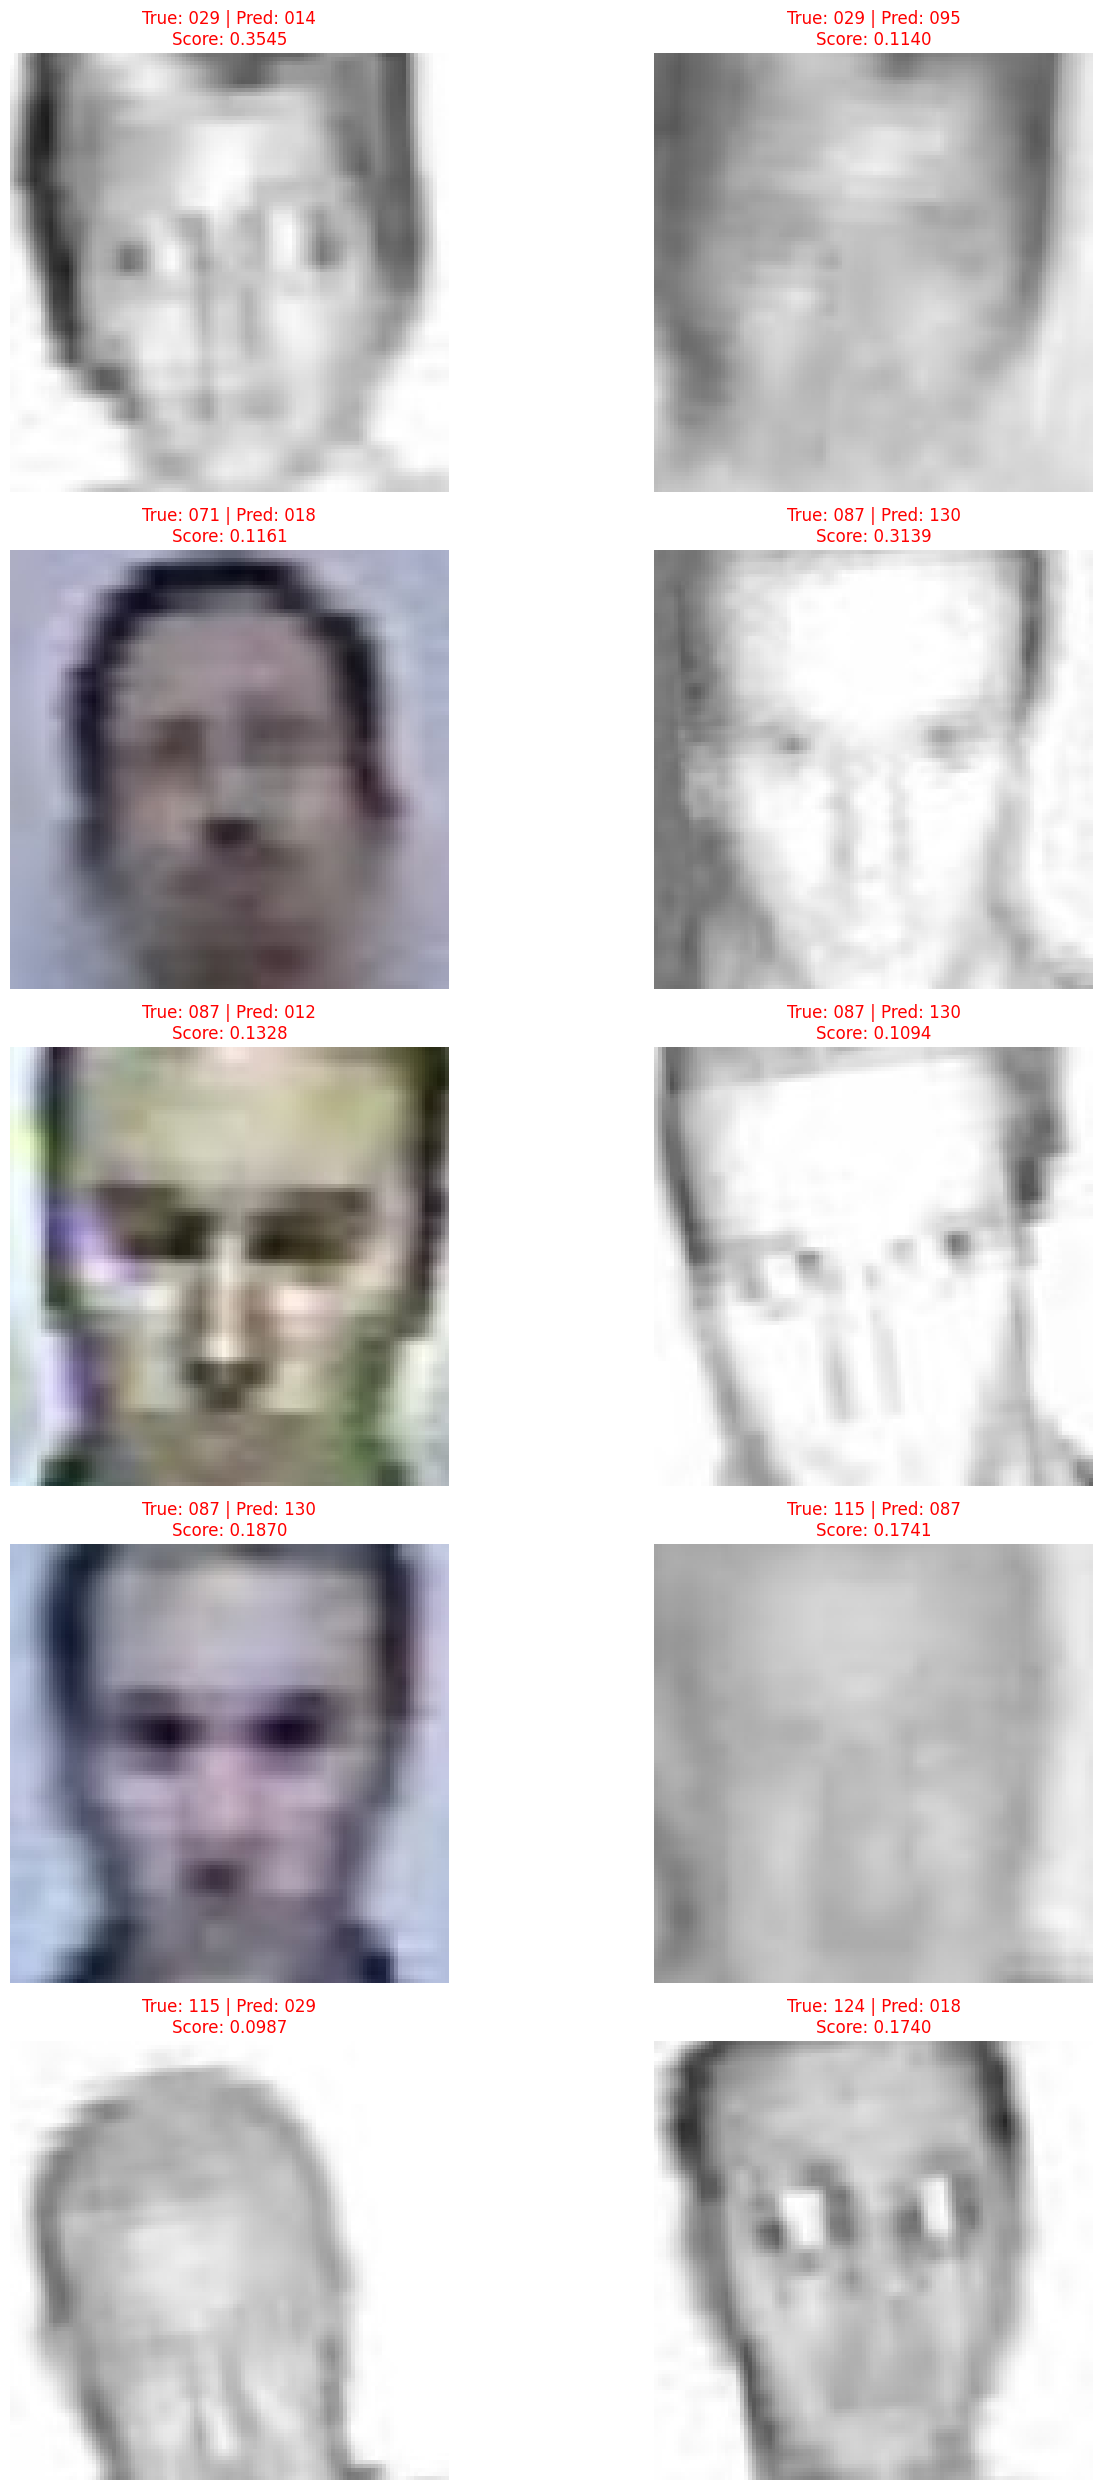

In [19]:
import matplotlib.pyplot as plt
import cv2

# Lấy tối đa 10 trường hợp sai để hiển thị trực quan
max_display = 10
display_list = mis_list[:max_display]

if not display_list:
    print("Không có trường hợp sai nào để hiển thị.")
else:
    num_images = len(display_list)
    cols = 2
    rows = (num_images + 1) // cols

    plt.figure(figsize=(15, 5 * rows))

    for i, item in enumerate(display_list):
        img = cv2.imread(item['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        title = f"True: {item['true']} | Pred: {item['pred']}\nScore: {item['score']:.4f}"
        plt.title(title, color='red', fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    if len(mis_list) > max_display:
        print(f"... và còn {len(mis_list) - max_display} trường hợp sai khác đã được liệt kê ở trên.")

Re-loading model for Grad-CAM...
Model re-loaded successfully.
Generating Grad-CAM for: /content/real_test/query/huy_ng_5.jpg


/content/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


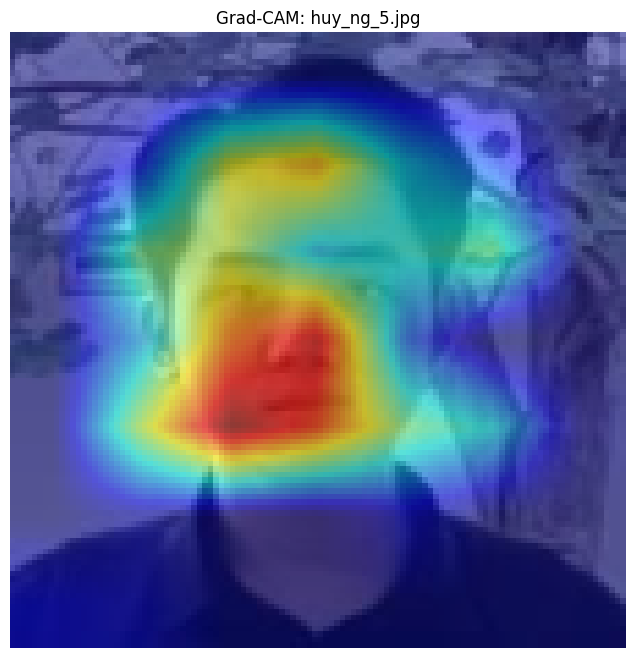

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from torchvision import transforms

# Import GradCAM and related utilities
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Import iresnet50 from the downloaded file
from iresnet import iresnet50

# --- Configuration ---
MODEL_PATH = "/content/drive/MyDrive/Do_An_CV/ir50_scface_best_arcface_unfreze_all.pth"
QUERY_DIR = "/content/real_test/query"
IMG_SIZE = 112
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Lấy danh sách file ảnh
query_files = sorted([f for f in os.listdir(QUERY_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

print("Re-loading model for Grad-CAM...")
model_grad_cam = iresnet50(fp16=False)
ckpt_grad_cam  = torch.load(MODEL_PATH, map_location=device)
clean_grad_cam = {k.replace('module.', ''): v for k, v in ckpt_grad_cam.items()}
model_grad_cam.load_state_dict(clean_grad_cam)
model_grad_cam.eval().to(device)
print("Model re-loaded successfully.")

# Target layer: layer cuối cùng của iresnet50
target_layers = [model_grad_cam.layer4[-1]]

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

if len(query_files) > 0:
    # Chọn ảnh đầu tiên để demo (huy_ng_5.jpg)
    selected_idx = 0
    example_img_path = os.path.join(QUERY_DIR, query_files[selected_idx])
    print(f"Generating Grad-CAM for: {example_img_path}")

    # Read and prepare the image
    img_bgr = cv2.imread(example_img_path)
    rgb_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    rgb_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))
    rgb_img_float = np.float32(rgb_img) / 255

    input_tensor = preprocess(rgb_img).unsqueeze(0).to(device)

    # Construct the CAM object (Xóa use_cuda vì bản mới không hỗ trợ tham số này)
    cam = GradCAM(model=model_grad_cam, target_layers=target_layers)

    # Compute CAM (targets=None sẽ lấy activation cao nhất của embedding)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]

    # Overlay
    cam_image = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    # Display
    plt.figure(figsize=(8, 8))
    plt.imshow(cam_image)
    plt.title(f'Grad-CAM: {query_files[selected_idx]}')
    plt.axis('off')
    plt.show()
else:
    print("Không tìm thấy file ảnh nào trong thư mục query.")

In [ ]:


import os
import cv2
import numpy as np
import torch
import zipfile
from skimage import transform as trans

# =============================================================================
# CONFIG — CHỈNH TẠI ĐÂY
# =============================================================================
ZIP_PATH    = "/content/drive/MyDrive/Do_An_CV/real_test.zip"       # path tới file zip
EXTRACT_DIR = "/content"                      # giải nén vào đây
MODEL_PATH  = "/content/drive/MyDrive/Do_An_CV/ir50_scface_best_arcface_unfreze_all.pth"

THRESHOLD   = 0.5   # cosine similarity — dưới ngưỡng này → "Unknown"
STEEPNESS   = 10     # độ dốc sigmoid (5=thoải, 10=cân bằng, 20=dốc)
DET_SIZE    = (640, 640)
IMG_SIZE    = 112

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# =============================================================================
# BƯỚC 1: GIẢI NÉN
# =============================================================================
print("\n[1/5] Giải nén dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

GALLERY_DIR = os.path.join(EXTRACT_DIR, "real_test", "gallery")
QUERY_DIR   = os.path.join(EXTRACT_DIR, "real_test", "query")
print(f"  Gallery: {GALLERY_DIR}")
print(f"  Query  : {QUERY_DIR}")

# =============================================================================
# BƯỚC 2: LOAD MODEL IR50
# =============================================================================
print("\n[2/5] Load model IR50...")
from iresnet import iresnet50

model = iresnet50(fp16=False)
ckpt  = torch.load(MODEL_PATH, map_location=device)
clean = {k.replace('module.', ''): v for k, v in ckpt.items()}
model.load_state_dict(clean)
model.eval().to(device)
print("  ✅ Model loaded")

# =============================================================================
# BƯỚC 3: LOAD DETECTOR (RetinaFace qua InsightFace)
# =============================================================================
print("\n[3/5] Load RetinaFace detector...")
from insightface.app import FaceAnalysis

detector = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

detector.prepare(ctx_id=0, det_size=DET_SIZE, det_thresh=0.7)
print("  ✅ Detector ready")

# =============================================================================
# ALIGN FACE (chuẩn ArcFace 112x112)
# =============================================================================
ARCFACE_DST = np.array([
    [38.2946, 51.6963],  # mắt trái
    [73.5318, 51.5014],  # mắt phải
    [56.0252, 71.7366],  # mũi
    [41.5493, 92.3655],  # miệng trái
    [70.7299, 92.2041],  # miệng phải
], dtype=np.float32)

def align_face(img, kps, size=112):
    tform = trans.SimilarityTransform()
    tform.estimate(kps, ARCFACE_DST)
    M = tform.params[:2]
    aligned = cv2.warpAffine(
        img, M, (size, size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    return aligned

def get_embedding(img_path):
    """
    Đọc ảnh → detect face → align → extract embedding.
    Trả về embedding (512-d, L2 normalized) hoặc None nếu thất bại.
    """


    img = cv2.imread(img_path)
    if img is None:
        return None, "cannot_read"

    faces = detector.get(img)

    # Fallback: upscale nếu ảnh nhỏ và không detect được
    if not faces:
        h, w = img.shape[:2]
        if max(h, w) < 300:
            for scale in [2, 3]:
                img_up = cv2.resize(img, (w*scale, h*scale),
                                    interpolation=cv2.INTER_CUBIC)
                faces = detector.get(img_up)
                if faces:
                    for f in faces:
                        f.kps = f.kps / scale
                    break

    if not faces:
        return None, "no_face"

    face = max(faces, key=lambda f: f.det_score)

    if face.det_score < 0.:
        return None, f"low_conf_{face.det_score:.2f}"

    if face.kps is None:
        return None, "no_landmarks"

    aligned = align_face(img, face.kps, IMG_SIZE)

    if np.mean(aligned) < 5:
        return None, "too_dark"

    # Preprocess
    aligned_rgb = cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)
    inp = (np.float32(aligned_rgb) - 127.5) / 128.0
    inp = np.transpose(inp, (2, 0, 1))
    tensor = torch.from_numpy(inp).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model(tensor).cpu().numpy()[0]

    emb = emb / np.linalg.norm(emb)
    return emb, "ok"

# =============================================================================
# BƯỚC 4: BUILD GALLERY
# Mỗi người: mean của tất cả embedding → 1 vector đại diện
# =============================================================================
print("\n[4/5] Building gallery...")
print("-" * 45)

gallery = {}  # {person_name: mean_embedding}
gallery_detail = {}  # {person_name: {"total": N, "success": M}}

for person in sorted(os.listdir(GALLERY_DIR)):
    person_dir = os.path.join(GALLERY_DIR, person)
    if not os.path.isdir(person_dir):
        continue

    embs = []
    files = [f for f in os.listdir(person_dir)
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    for fname in files:
        emb, status = get_embedding(os.path.join(person_dir, fname))
        if emb is not None:
            embs.append(emb)

    gallery_detail[person] = {"total": len(files), "success": len(embs)}

    if embs:
        mean_emb = np.mean(embs, axis=0)
        mean_emb = mean_emb / np.linalg.norm(mean_emb)  # re-normalize
        gallery[person] = mean_emb
        print(f"  {person:<15}: {len(embs)}/{len(files)} ảnh → ✅ embedding ready")
    else:
        print(f"  {person:<15}: 0/{len(files)} ảnh → ❌ skip")

print(f"\n  Gallery: {len(gallery)} người")

# =============================================================================
# CONFIDENCE: Cosine → % bằng sigmoid
# =============================================================================
def cosine_to_conf(score, threshold=THRESHOLD, steepness=STEEPNESS):
    """
    Sigmoid centered tại threshold:
      score >> threshold → conf gần 100%
      score == threshold → conf = 50%
      score << threshold → conf gần 0%
    """
    conf = 1.0 / (1.0 + np.exp(-steepness * (score - threshold)))
    return conf * 100.0

def conf_bar(conf, width=20):
    """Thanh progress bar ASCII."""
    filled = int(conf / 100 * width)
    return "█" * filled + "░" * (width - filled)

# =============================================================================
# BƯỚC 5: NHẬN DIỆN QUERY
# =============================================================================
print("\n[5/5] Nhận diện query images...")
print("=" * 70)
print(f"  Threshold = {THRESHOLD} | Steepness = {STEEPNESS}")
print("=" * 70)

query_files = sorted([
    f for f in os.listdir(QUERY_DIR)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])

results = []

for fname in query_files:
    query_path = os.path.join(QUERY_DIR, fname)
    probe_emb, status = get_embedding(query_path)

    if probe_emb is None:
        print(f"\n  ⚠️  {fname}: {status}")
        results.append({
            "file": fname, "pred": "ERROR",
            "score": 0.0, "conf": 0.0, "status": status
        })
        continue

    # Tính cosine similarity với từng người trong gallery
    sims = {
        pid: float(np.dot(probe_emb, gemb))
        for pid, gemb in gallery.items()
    }
    best_id    = max(sims, key=sims.get)
    best_score = sims[best_id]
    conf       = cosine_to_conf(best_score)

    # Quyết định Known / Unknown
    if best_score >= THRESHOLD:
        pred   = best_id
        label  = "✅ KNOWN"
    else:
        pred   = "Unknown"
        label  = "🚫 UNKNOWN"

    # In kết quả
    bar = conf_bar(conf)
    print(f"\n  📷 {fname}")
    print(f"     Predicted : {pred}")
    print(f"     Score     : {best_score:.4f}  |  Confidence: {conf:.1f}%")
    print(f"     [{bar}] {label}")

    # In top-3 candidates
    top3 = sorted(sims.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"     Top-3     : " +
          "  |  ".join(f"{p}: {s:.3f}" for p, s in top3))

    results.append({
        "file": fname, "pred": pred,
        "score": best_score, "conf": conf, "status": "ok"
    })

# =============================================================================
# BÁO CÁO CUỐI
# =============================================================================
print("\n" + "=" * 70)
print("  📊 BÁO CÁO TỔNG KẾT")
print("=" * 70)
print(f"  {'File':<25} {'Predicted':<12} {'Score':>7}  {'Conf':>7}  {'Decision'}")
print("  " + "-" * 65)

for r in results:
    decision = "Known" if r["pred"] not in ("Unknown", "ERROR") else r["pred"]
    print(f"  {r['file']:<25} {r['pred']:<12} "
          f"{r['score']:>7.4f}  {r['conf']:>6.1f}%  {decision}")

# Thống kê
known_count   = sum(1 for r in results if r["pred"] not in ("Unknown", "ERROR"))
unknown_count = sum(1 for r in results if r["pred"] == "Unknown")
error_count   = sum(1 for r in results if r["pred"] == "ERROR")

print("  " + "-" * 65)
print(f"  Tổng query : {len(results)}")
print(f"  ✅ Known   : {known_count}")
print(f"  🚫 Unknown : {unknown_count}")
if error_count:
    print(f"  ⚠️  Error  : {error_count}")
print("=" * 70)

Device: cuda

[1/5] Giải nén dataset...
  Gallery: /content/real_test/gallery
  Query  : /content/real_test/query

[2/5] Load model IR50...
  ✅ Model loaded

[3/5] Load RetinaFace detector...
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 96327.39KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
  ✅ Detector

/content/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


  huy            : 7/7 ảnh → ✅ embedding ready
  quan           : 7/7 ảnh → ✅ embedding ready
  tien           : 6/6 ảnh → ✅ embedding ready
  tuan           : 4/4 ảnh → ✅ embedding ready

  Gallery: 4 người

[5/5] Nhận diện query images...
  Threshold = 0.5 | Steepness = 10

  📷 huy_ng_5.jpg
     Predicted : huy
     Score     : 0.8780  |  Confidence: 97.8%
     [███████████████████░] ✅ KNOWN
     Top-3     : huy: 0.878  |  quan: 0.401  |  tuan: 0.381

  📷 huy_tr_1.jpg
     Predicted : huy
     Score     : 0.8810  |  Confidence: 97.8%
     [███████████████████░] ✅ KNOWN
     Top-3     : huy: 0.881  |  tuan: 0.430  |  quan: 0.369

  📷 kiet_1.jpg
     Predicted : Unknown
     Score     : 0.4214  |  Confidence: 31.3%
     [██████░░░░░░░░░░░░░░] 🚫 UNKNOWN
     Top-3     : huy: 0.421  |  quan: 0.392  |  tuan: 0.313

  📷 kiet_2.jpg
     Predicted : Unknown
     Score     : 0.2995  |  Confidence: 11.9%
     [██░░░░░░░░░░░░░░░░░░] 🚫 UNKNOWN
     Top-3     : huy: 0.299  |  quan: 0.258  |  tuan